In [44]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**DATA CLEANING AND DATA PREPROCESSING**

In [45]:
#loading the dataset
datasetflix1 = pd.read_csv(
    'netflixmoviedb.csv',
    engine='python',
    encoding='utf-8',
    on_bad_lines='skip'
)

In [46]:
#dataset preview
datasetflix1.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [47]:
#getting basic information about the dataset
datasetflix1.info()

<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   str    
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   str    
 5   Vote_Average       9827 non-null   str    
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
dtypes: float64(1), str(8)
memory usage: 691.8 KB


In [48]:
#basic info about the genre column
datasetflix1['Genre'].head(10)

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
5               Action, Crime, Thriller
6             Horror, Mystery, Thriller
7                              Thriller
8                Action, Crime, Fantasy
9                       Science Fiction
Name: Genre, dtype: str

In [49]:
#checking for duplicates in the dataset
datasetflix1.duplicated().sum()

np.int64(0)

In [50]:
#descriptive statistics for the popularity column
datasetflix1['Popularity'].describe()

count    9827.000000
mean       40.320570
std       108.874308
min         7.100000
25%        16.127500
50%        21.191000
75%        35.174500
max      5083.954000
Name: Popularity, dtype: float64

In [51]:
#descriptive statistics for the vote count and vote average columns
datasetflix1[['Vote_Count', 'Vote_Average']].describe()

,Vote_Count,Vote_Average
count,9827,9827
unique,3267,75
top,0,6.4
freq,100,435


In [52]:
#descriptive statistics for the popularity column
datasetflix1['Popularity'].describe()

count    9827.000000
mean       40.320570
std       108.874308
min         7.100000
25%        16.127500
50%        21.191000
75%        35.174500
max      5083.954000
Name: Popularity, dtype: float64

In [53]:
datasetflix1.dtypes

Release_Date             str
Title                    str
Overview                 str
Popularity           float64
Vote_Count               str
Vote_Average             str
Original_Language        str
Genre                    str
Poster_Url               str
dtype: object

In [54]:
#converting the release date column to datetime format
datasetflix1['Release_Date'] = pd.to_datetime(
    datasetflix1['Release_Date'],
    errors='coerce'
)

In [55]:
datasetflix1.dtypes

Release_Date         datetime64[us]
Title                           str
Overview                        str
Popularity                  float64
Vote_Count                      str
Vote_Average                    str
Original_Language               str
Genre                           str
Poster_Url                      str
dtype: object

In [56]:
#extracting the release year from the release date column
datasetflix1['Release_Year'] = datasetflix1['Release_Date'].dt.year

In [57]:
#coverting the release year column to integer type from float type
datasetflix1['Release_Year'] = datasetflix1['Release_Year'].astype('Int64')

In [58]:
datasetflix1[['Release_Date', 'Release_Year']].head()

,Release_Date,Release_Year
0,2021-12-15,2021
1,2022-03-01,2022
2,2022-02-25,2022
3,2021-11-24,2021
4,2021-12-22,2021


In [59]:
#dropping unnecessary columns
dropcoln = ['Overview', 'Original_Language', 'Poster_Url', 'Release_Date']
datasetflix1.drop(dropcoln, axis=1, inplace=True)

In [60]:
datasetflix1.head()

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",2021
1,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",2022
2,No Exit,2618.087,122,6.3,Thriller,2022
3,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",2021
4,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",2021


In [61]:
# how the popularity column is categorized based on the above ranges (for personal understanding)
# example:
# Range(edges)      Label
4.0-5.8	    #not_popular
5.8-6.9	    #below_avg
6.9-7.7	    #average
7.7-9.2     #popular


-1.4999999999999991

In [62]:
print(datasetflix1['Vote_Average'].dtype)
print(datasetflix1['Vote_Average'].head())


str
0    8.3
1    8.1
2    6.3
3    7.7
4    7.0
Name: Vote_Average, dtype: str


In [63]:
#converting the vote average column to numeric type from object type
datasetflix1['Vote_Average'] = pd.to_numeric(datasetflix1['Vote_Average'], errors='coerce')

In [64]:
#checking the unique values in the vote average column
def categorize_col(df, col, labels):
    col_min  = df[col].min()
    col_25   = df[col].quantile(0.25)
    col_50   = df[col].quantile(0.50)
    col_75   = df[col].quantile(0.75)
    col_max  = df[col].max()

    edges = [col_min, col_25, col_50, col_75, col_max]
    df[col] = pd.cut(df[col], bins=edges, labels=labels, include_lowest=True)
    return df

In [65]:
# Categorizing the vote average column
labels = ['not_popular', 'below_avg', 'average', 'popular']

if datasetflix1['Vote_Average'].dtype != 'category':
    categorize_col(datasetflix1, 'Vote_Average', labels)

datasetflix1['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, str): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [66]:
datasetflix1.head(15)

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction",2021
1,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller",2022
2,No Exit,2618.087,122,below_avg,Thriller,2022
3,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy",2021
4,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War",2021
5,The Commando,1750.484,33,average,"Action, Crime, Thriller",2022
6,Scream,1675.161,821,average,"Horror, Mystery, Thriller",2022
7,Kimi,1601.782,206,below_avg,Thriller,2022
8,Fistful of Vengeance,1594.013,114,not_popular,"Action, Crime, Fantasy",2022
9,Eternals,1537.406,4726,popular,Science Fiction,2021


In [67]:
datasetflix1['Vote_Average'].value_counts()

Vote_Average
not_popular    2567
popular        2450
average        2411
below_avg      2398
Name: count, dtype: int64

In [68]:
#checking for missing values in the dataset
datasetflix1.dropna(inplace = True)
datasetflix1.isna().sum()

Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
Release_Year    0
dtype: int64

In [69]:
# split the strings into lists
datasetflix1['Genre'] = datasetflix1['Genre'].str.split(', ')
# explode the lists
datasetflix1 = datasetflix1.explode('Genre').reset_index(drop=True)
datasetflix1.head()

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,Spider-Man: No Way Home,5083.954,8940,popular,Action,2021
1,Spider-Man: No Way Home,5083.954,8940,popular,Adventure,2021
2,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction,2021
3,The Batman,3827.658,1151,popular,Crime,2022
4,The Batman,3827.658,1151,popular,Mystery,2022


In [70]:
# casting column into category
datasetflix1['Genre'] = datasetflix1['Genre'].astype('category')
# confirming changes
datasetflix1['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=str)

In [71]:
datasetflix1.info()

<class 'pandas.DataFrame'>
RangeIndex: 25792 entries, 0 to 25791
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Title         25792 non-null  str     
 1   Popularity    25792 non-null  float64 
 2   Vote_Count    25792 non-null  str     
 3   Vote_Average  25792 non-null  category
 4   Genre         25792 non-null  category
 5   Release_Year  25792 non-null  Int64   
dtypes: Int64(1), category(2), float64(1), str(2)
memory usage: 882.0 KB


In [74]:
datasetflix1.nunique()

Title           9512
Popularity      8159
Vote_Count      3266
Vote_Average       4
Genre             19
Release_Year     102
dtype: int64

**DATA VISUALIZATION**

In [76]:
# setting up seaborn configurations
sns.set_style('whitegrid')

**Q1: What is the most frequent genre in
the dataset?**

In [79]:
# showing stats. on genre column
datasetflix1['Genre'].describe()

count     25792
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

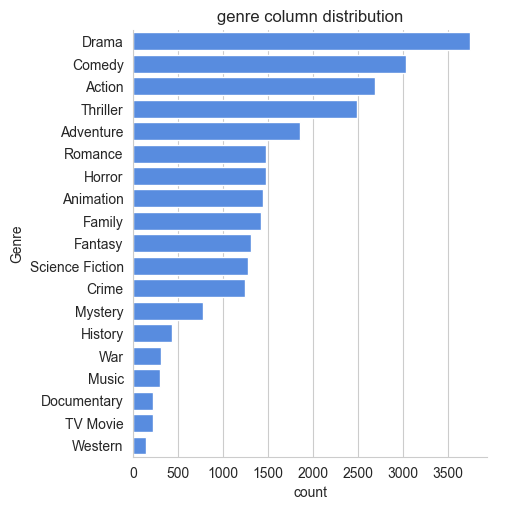

In [81]:
# visualizing genre column
sns.catplot(y = 'Genre', data = datasetflix1, kind = 'count',
 order = datasetflix1['Genre'].value_counts().index,
 color = '#4287f5')
plt.title('genre column distribution')
plt.show()

**Q2: What genres has highest votes ?**

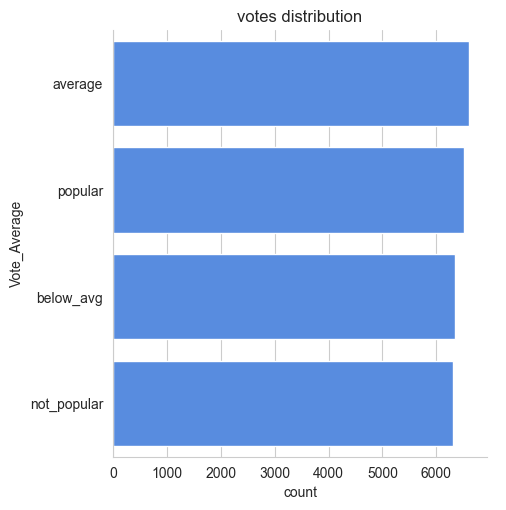

In [82]:
# visualizing vote_average column
sns.catplot(y = 'Vote_Average', data = datasetflix1, kind = 'count',
 order = datasetflix1['Vote_Average'].value_counts().index,
 color = '#4287f5')
plt.title('votes distribution')
plt.show()

**Q3: What movie got the highest popularity ? what's its
genre ?**

In [83]:
# checking max popularity in dataset
datasetflix1[datasetflix1['Popularity'] == datasetflix1['Popularity'].max()]

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,Spider-Man: No Way Home,5083.954,8940,popular,Action,2021
1,Spider-Man: No Way Home,5083.954,8940,popular,Adventure,2021
2,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction,2021


**Q4: What movie got the lowest popularity? what's
its genre?**

In [84]:
# checking max popularity in dataset
datasetflix1[datasetflix1['Popularity'] == datasetflix1['Popularity'].min()]

,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
25786,The United States vs. Billie Holiday,13.354,152,average,Music,2021
25787,The United States vs. Billie Holiday,13.354,152,average,Drama,2021
25788,The United States vs. Billie Holiday,13.354,152,average,History,2021
25789,Threads,13.354,186,popular,War,1984
25790,Threads,13.354,186,popular,Drama,1984
25791,Threads,13.354,186,popular,Science Fiction,1984


**Q5: Which year has the most filmmed movies?**

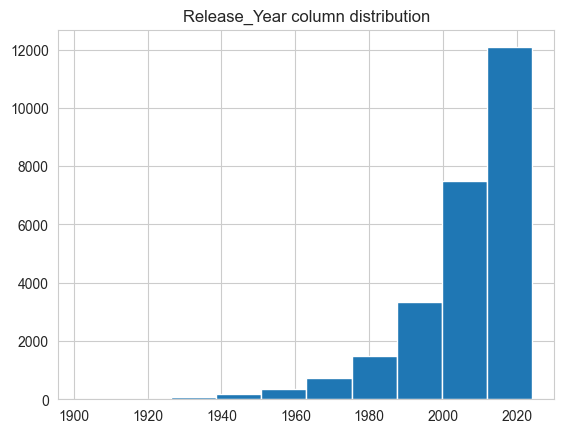

In [89]:
datasetflix1['Release_Year'].hist()
plt.title('Release_Year column distribution')
plt.show()

**Q1: What is the most frequent genre in the dataset?**

The Drama genre is the most frequent genre in the dataset, accounting for more than 14% of all genre occurrences among the 19 available genres.

**Q2: Which genre has the highest number of votes?**

Approximately 25.5% of the dataset (6,520 movies) received high popularity votes. Among all genres, Drama recorded the highest audience popularity, contributing to more than 18.5% of the highly voted movies.

**Q3: Which movie has the highest popularity, and what is its genre?**

Spider-Man: No Way Home has the highest popularity score in the dataset. Its genres are Action, Adventure, and Science Fiction.

**Q4: Which movie has the lowest popularity, and what is its genre?**

The United States, Thread has the lowest popularity score in the dataset. Its genres include Music, Drama, War, Science Fiction, and History.

**Q5: Which year had the highest number of filmed movies?**

The year 2020 recorded the highest number of movies produced in the dataset.